# 08 — Fairness / Equity Evaluation and Baseline Comparison

Closes the two gaps your paper (Section V-J) and guide's feedback both flagged as missing:

1. **Equity validation** — a real fairness analysis beyond citing the Gini coefficient in passing:
   need-satisfaction ratio by priority tier, allocation per affected person, and a second
   fairness index (Jain's index) alongside Gini.
2. **Baseline vs. optimized allocation** — a naive allocation (proportional-to-request) compared
   against the NSGA-II Balanced scenario on the same metrics, so "the optimizer helps" is a
   demonstrated result, not an assumed one.

Run this **after** notebooks 02, 04/05, and 06, since it loads their saved outputs. Nothing here
re-runs the optimizer — it only evaluates what 06 already produced, plus one new baseline.

## 0. Setup and locate your saved files

Same `CLEAN_DIR` convention as every other notebook in this project. The cell below also lists
every `phase2_*` / `phase3_*` / `final_need*` file actually sitting in that folder, because the
exact filenames from notebooks 04–06 should be confirmed here rather than assumed — same
principle used for the school/GP mapping earlier: verify before trusting.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
import numpy as np
import os

BASE_DIR = "/content/drive/MyDrive/Colab Notebooks/Data_Organized"
CLEAN_DIR = os.path.join(BASE_DIR, "Cleaned")

print("Files matching this notebook's needs:")
for f in sorted(os.listdir(CLEAN_DIR)):
    if f.startswith(("phase2", "phase3", "final_need", "gp_sector_need")):
        print(" ", f)

Files matching this notebook's needs:
  final_need_assessment.csv
  gp_sector_need_scores.csv
  phase2_feature_importance.png
  phase2_final_predictions.csv
  phase2_model_performance.csv
  phase2_tuned_model_performance.csv
  phase2_uncertainty_chart.png
  phase3_allocations_by_scenario.csv
  phase3_pareto_front.png
  phase3_scenario_summary.csv
  phase3_sensitivity_analysis.csv
  phase3_sensitivity_chart.png


## 1. Confirm filenames and load

**Edit the four paths below** if Step 0's listing printed different filenames than the defaults
here. Each load prints its shape and columns so you can catch a mismatch immediately rather than
debugging a KeyError three cells later.

In [3]:
# --- EDIT THESE if Step 0 showed different filenames ---
NEED_ASSESSMENT_FILE = os.path.join(CLEAN_DIR, "final_need_assessment.csv")
SECTOR_NEED_FILE      = os.path.join(CLEAN_DIR, "gp_sector_need_scores.csv")
PROJECT_TABLE_FILE    = os.path.join(CLEAN_DIR, "phase2_final_predictions.csv")
ALLOCATIONS_FILE      = os.path.join(CLEAN_DIR, "phase3_allocations_by_scenario.csv")
# ---------------------------------------------------------

need_assessment = pd.read_csv(NEED_ASSESSMENT_FILE)
sector_need     = pd.read_csv(SECTOR_NEED_FILE)
project_table   = pd.read_csv(PROJECT_TABLE_FILE)
allocations     = pd.read_csv(ALLOCATIONS_FILE)

for name, df in [("need_assessment", need_assessment), ("sector_need", sector_need),
                  ("project_table", project_table), ("allocations", allocations)]:
    print(f"\n{name}: {df.shape}")
    print(" columns:", df.columns.tolist())


need_assessment: (33, 18)
 columns: ['gp_name', 'need_rank', 'need_score_raw', 'need_score_100', 'priority_category', 'child_share', 'illiteracy_rate', 'marginal_worker_share', 'non_worker_share', 'school_college_deficiency', 'all_weather_road_deficiency', 'internal_pucca_road_deficiency', 'transport_deficiency', 'electricity_deficiency', 'drainage_deficiency', 'health_facility_deficiency', 'education_data_available', 'education_need_subindex']

sector_need: (198, 4)
 columns: ['gp_name', 'sector', 'sector_need_score', 'n_indicators_in_sector']

project_table: (198, 12)
 columns: ['gp_name', 'sector', 'proposed_budget_lakh', 'historical_expenditure_lakh', 'population_affected', 'sector_need_score', 'synthetic_impact', 'predicted_impact', 'predicted_impact_lower_90', 'predicted_impact_upper_90', 'uncertainty_width', 'prediction_model']

allocations: (198, 9)
 columns: ['gp_name', 'sector', 'proposed_budget_lakh', 'sector_need_score', 'predicted_impact', 'allocation_impact_first_lakh', 

## 2. Map your actual columns

**Fill in the right-hand side of each line below** using the column names Step 1 just printed.
This is the only place column names are hardcoded — every later cell uses these variables, so a
mismatch here is a one-line fix instead of a search-and-replace through the notebook.

In [4]:
# --- EDIT THESE to match the columns printed in Step 1 ---
COL_GP            = "gp_name"            # GP identifier, present in all four tables
COL_SECTOR        = "sector"             # sector name, in project_table / allocations
COL_COST          = "proposed_budget_lakh"   # requested cost c_k, in project_table
COL_PRED_IMPACT   = "predicted_impact"   # I_k at full funding, in project_table or allocations
COL_SECTOR_NEED   = "sector_need_score"  # N_is, in project_table
COL_POP_AFFECTED  = "population_affected"
COL_PRIORITY      = "priority_category"  # Lower/Moderate/Higher Need, in need_assessment
COL_ALLOC_BALANCED = "allocation_balanced_lakh"  # a_k under the Balanced NSGA-II scenario, in allocations
# -----------------------------------------------------------

required = [COL_GP, COL_SECTOR, COL_COST, COL_PRED_IMPACT, COL_SECTOR_NEED, COL_POP_AFFECTED]
missing = [c for c in required if c not in project_table.columns]
assert not missing, f"These columns are not in project_table -- fix the mapping above: {missing}"
assert COL_ALLOC_BALANCED in allocations.columns, \
    f"'{COL_ALLOC_BALANCED}' not in allocations -- check Step 1's printed column list and fix above"
assert COL_PRIORITY in need_assessment.columns, \
    f"'{COL_PRIORITY}' not in need_assessment -- check Step 1's printed column list and fix above"

print("All required columns found. Proceeding.")

All required columns found. Proceeding.


## 3. Assemble the evaluation table

One row per GP-sector project (198 rows), carrying: requested cost, predicted impact, sector
Need Score, population affected, priority tier, and the Balanced-scenario allocation from
Notebook 06.

In [5]:
df = project_table[[COL_GP, COL_SECTOR, COL_COST, COL_PRED_IMPACT,
                     COL_SECTOR_NEED, COL_POP_AFFECTED]].copy()
df.columns = ["gp_name", "sector", "cost", "impact_full", "need_score", "population_affected"]

df = df.merge(
    allocations[[COL_GP, COL_SECTOR, COL_ALLOC_BALANCED]].rename(
        columns={COL_GP: "gp_name", COL_SECTOR: "sector", COL_ALLOC_BALANCED: "alloc_optimized"}
    ),
    on=["gp_name", "sector"], how="left"
)

df = df.merge(
    need_assessment[[COL_GP, COL_PRIORITY]].rename(
        columns={COL_GP: "gp_name", COL_PRIORITY: "priority_tier"}
    ),
    on="gp_name", how="left"
)

missing_alloc = df["alloc_optimized"].isna().sum()
missing_tier = df["priority_tier"].isna().sum()
print("Rows:", len(df))
print("Missing optimized allocation (should be 0):", missing_alloc)
print("Missing priority tier (should be 0):", missing_tier)
if missing_alloc or missing_tier:
    print("WARNING -- a merge key did not match. Check GP name spelling consistency before proceeding.")

display(df.head())

Rows: 198
Missing optimized allocation (should be 0): 0
Missing priority tier (should be 0): 0


,gp_name,sector,cost,impact_full,need_score,population_affected,alloc_optimized,priority_tier
0,Alkod,education,10.614423,0.423865,0.700158,3972,9.44,Higher Need
1,Alkod,electricity_infra,15.727554,0.286105,0.083333,4626,6.83,Higher Need
2,Alkod,health,12.562725,0.519388,0.750000,3119,9.22,Higher Need
3,Alkod,livelihood,18.285669,0.421419,0.396035,969,7.93,Higher Need
4,Alkod,roads_transport,18.605972,0.657110,0.838557,2633,17.41,Higher Need


## 4. Build the baseline (naive) allocation

Proportional-to-request: every project receives the same **share** of the available budget
relative to what it asked for, with no consideration of need or predicted impact. This is the
closest honest proxy for "how funds are often split today" and is what the NSGA-II result should
be compared against -- it is intentionally simple, not a strawman.

Uses the **same total budget** as the Balanced NSGA-II scenario, so the comparison is apples to
apples.

In [6]:
B = df["alloc_optimized"].sum()  # same total budget actually used by the Balanced scenario
print(f"Total budget being compared at: Rs {B:,.2f} lakh")

df["alloc_baseline"] = df["cost"] / df["cost"].sum() * B

# sanity check -- baseline must also respect each project's own cost cap
over_cap = (df["alloc_baseline"] > df["cost"] + 1e-6).sum()
print("Baseline rows exceeding their own requested cost (should be 0):", over_cap)
print("Baseline budget utilization: {:.2f}%".format(100 * df["alloc_baseline"].sum() / B))

Total budget being compared at: Rs 1,633.22 lakh
Baseline rows exceeding their own requested cost (should be 0): 0
Baseline budget utilization: 100.00%


## 5. Compute the same metrics for both allocations

Funded fraction, realized impact, need-weighted impact, and unmet need -- identical formulas to
what Notebook 06 used for the NSGA-II scenarios (see the Formula Reference document, items F12
and F14), applied here to both `alloc_baseline` and `alloc_optimized` so the two are directly
comparable.

In [7]:
def evaluate(alloc_col):
    f = df[alloc_col] / df["cost"]                       # funded fraction
    impact_realized = df["impact_full"] * f               # Î_k = I_k * f_k
    need_weighted = (df["need_score"] * impact_realized).sum()
    unmet_need = (df["need_score"] * (1 - f)).sum()
    utilization = 100 * df[alloc_col].sum() / B
    return pd.Series({
        "total_allocated": df[alloc_col].sum(),
        "budget_utilization_pct": utilization,
        "total_predicted_impact": impact_realized.sum(),
        "need_weighted_impact": need_weighted,
        "unmet_need": unmet_need,
    })

results = pd.DataFrame({
    "Baseline (proportional-to-request)": evaluate("alloc_baseline"),
    "NSGA-II Balanced": evaluate("alloc_optimized"),
})
display(results.round(3))

,Baseline (proportional-to-request),NSGA-II Balanced
total_allocated,1633.220,1633.220
budget_utilization_pct,100.000,100.000
total_predicted_impact,41.739,46.478
need_weighted_impact,20.841,25.829
unmet_need,29.895,20.529


## 6. Equity metrics -- Gini and Jain's index

Gini alone is one lens. Jain's fairness index gives a second, independently-interpretable view:
it ranges from 1/n (maximally unfair -- all funding to one project) to 1 (perfectly equal funding
fractions across all projects). Reporting both, rather than Gini alone, is what turns "equity
mentioned in passing" into an actual equity evaluation.

In [8]:
def gini(x):
    x = np.sort(np.asarray(x, dtype=float))
    n = len(x)
    if x.sum() == 0:
        return 0.0
    cum = np.cumsum(x)
    return (n + 1 - 2 * (cum / cum[-1]).sum()) / n

def jain_index(x):
    x = np.asarray(x, dtype=float)
    if (x**2).sum() == 0:
        return 1.0
    return (x.sum() ** 2) / (len(x) * (x**2).sum())

for label, col in [("Baseline", "alloc_baseline"), ("NSGA-II Balanced", "alloc_optimized")]:
    f = df[col] / df["cost"]
    print(f"{label:20s}  Gini = {gini(f):.4f}   Jain's index = {jain_index(f):.4f}")

Baseline              Gini = 0.0000   Jain's index = 1.0000
NSGA-II Balanced      Gini = 0.1809   Jain's index = 0.9060


## 7. Need-satisfaction ratio by priority tier

The core equity question: **do higher-need GPs actually get funded more fully than lower-need
GPs?** For each priority tier (Lower / Moderate / Higher Need), this computes the average funded
fraction under both allocations. If NSGA-II is doing its job, the Higher-Need tier's average
funded fraction should be at or above the baseline's -- this is the result to report as your
equity validation finding, whatever it actually shows.

In [9]:
df["funded_frac_baseline"] = df["alloc_baseline"] / df["cost"]
df["funded_frac_optimized"] = df["alloc_optimized"] / df["cost"]
df["alloc_per_affected_baseline"] = df["alloc_baseline"] / df["population_affected"].replace(0, np.nan)
df["alloc_per_affected_optimized"] = df["alloc_optimized"] / df["population_affected"].replace(0, np.nan)

tier_summary = df.groupby("priority_tier").agg(
    n_projects=("gp_name", "count"),
    avg_funded_frac_baseline=("funded_frac_baseline", "mean"),
    avg_funded_frac_optimized=("funded_frac_optimized", "mean"),
    avg_alloc_per_affected_baseline=("alloc_per_affected_baseline", "mean"),
    avg_alloc_per_affected_optimized=("alloc_per_affected_optimized", "mean"),
)

# order tiers Lower -> Moderate -> Higher if those exact labels are present
tier_order = [t for t in ["Lower Need", "Moderate Need", "Higher Need"] if t in tier_summary.index]
if tier_order:
    tier_summary = tier_summary.loc[tier_order]

display(tier_summary.round(4))

print("\nInterpretation check:")
if set(["Lower Need","Higher Need"]).issubset(tier_summary.index):
    lo = tier_summary.loc["Lower Need", "avg_funded_frac_optimized"]
    hi = tier_summary.loc["Higher Need", "avg_funded_frac_optimized"]
    print(f"Higher-Need avg funded fraction ({hi:.3f}) vs Lower-Need ({lo:.3f}) under NSGA-II.")
    print("This is the sentence to put directly in the paper's equity validation paragraph -- "
          "state the actual direction, do not assume it favors Higher-Need.")

,n_projects,avg_funded_frac_baseline,avg_funded_frac_optimized,avg_alloc_per_affected_baseline,avg_alloc_per_affected_optimized
priority_tier,,,,,
Lower Need,66,0.5994,0.5909,0.0052,0.0044
Moderate Need,66,0.5994,0.6408,0.0056,0.0060
Higher Need,66,0.5994,0.6836,0.0059,0.0065



Interpretation check:
Higher-Need avg funded fraction (0.684) vs Lower-Need (0.591) under NSGA-II.
This is the sentence to put directly in the paper's equity validation paragraph -- state the actual direction, do not assume it favors Higher-Need.


## 8. Comparison chart and save outputs

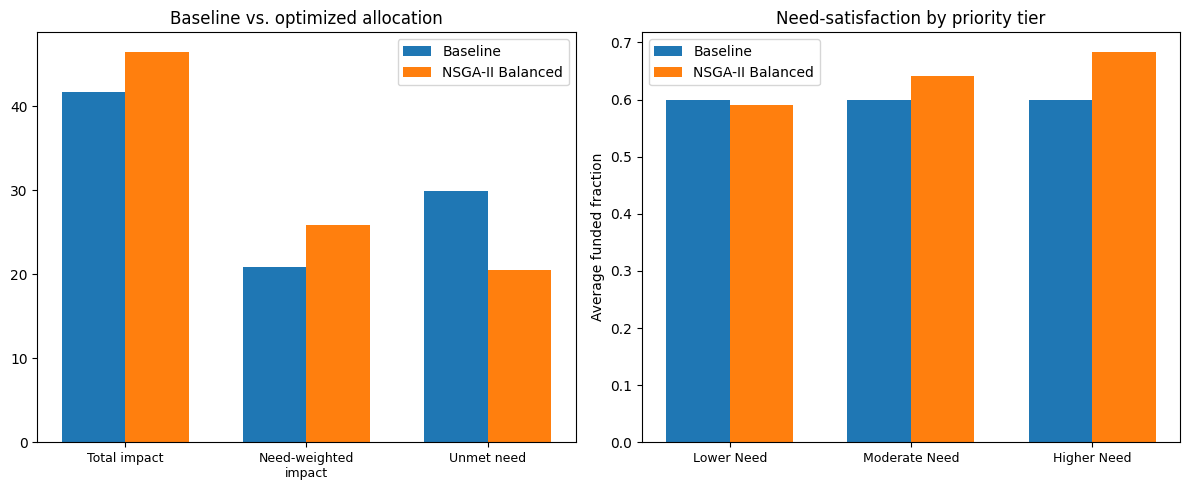

Saved:
 phase4b_fairness_equity_chart.png
 phase4b_baseline_vs_optimized.csv
 phase4b_need_satisfaction_by_tier.csv
 phase4b_fairness_evaluation_full.csv


In [10]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

metrics = ["total_predicted_impact", "need_weighted_impact", "unmet_need"]
x = np.arange(len(metrics))
w = 0.35
axes[0].bar(x - w/2, results.loc[metrics, "Baseline (proportional-to-request)"], w, label="Baseline")
axes[0].bar(x + w/2, results.loc[metrics, "NSGA-II Balanced"], w, label="NSGA-II Balanced")
axes[0].set_xticks(x)
axes[0].set_xticklabels(["Total impact", "Need-weighted\nimpact", "Unmet need"], fontsize=9)
axes[0].set_title("Baseline vs. optimized allocation")
axes[0].legend()

tiers = tier_summary.index.tolist()
x2 = np.arange(len(tiers))
axes[1].bar(x2 - w/2, tier_summary["avg_funded_frac_baseline"], w, label="Baseline")
axes[1].bar(x2 + w/2, tier_summary["avg_funded_frac_optimized"], w, label="NSGA-II Balanced")
axes[1].set_xticks(x2)
axes[1].set_xticklabels(tiers, fontsize=9)
axes[1].set_ylabel("Average funded fraction")
axes[1].set_title("Need-satisfaction by priority tier")
axes[1].legend()

plt.tight_layout()
plt.savefig(os.path.join(CLEAN_DIR, "phase4b_fairness_equity_chart.png"), dpi=150, bbox_inches="tight")
plt.show()

results.to_csv(os.path.join(CLEAN_DIR, "phase4b_baseline_vs_optimized.csv"))
tier_summary.to_csv(os.path.join(CLEAN_DIR, "phase4b_need_satisfaction_by_tier.csv"))
df.to_csv(os.path.join(CLEAN_DIR, "phase4b_fairness_evaluation_full.csv"), index=False)

print("Saved:")
print(" phase4b_fairness_equity_chart.png")
print(" phase4b_baseline_vs_optimized.csv")
print(" phase4b_need_satisfaction_by_tier.csv")
print(" phase4b_fairness_evaluation_full.csv")

## 9. Summary for the paper

Fill in the blanks below using your own printed numbers from Steps 5–7 once this has run --
don't guess the direction before seeing the actual result.

> *Equity was evaluated using two complementary measures: the Gini coefficient and Jain's
> fairness index, applied to the funded fraction of each GP-sector project. The NSGA-II Balanced
> scenario achieved a Gini of ____ and a Jain's index of ____, compared to ____ and ____ for a
> proportional-to-request baseline allocating the same total budget. Need-satisfaction, measured
> as the average funded fraction by priority tier, was ____ for Higher-Need GPs versus ____ for
> Lower-Need GPs under the optimized allocation, compared to ____ and ____ under the baseline.
> This indicates that the optimization [does / does not] preferentially direct funding toward
> higher-need Panchayats relative to a naive proportional split.*

If the result does **not** favor Higher-Need GPs, report that honestly -- it is still a valid and
useful finding (it may mean `F2`'s need-weighting term needs a larger relative weight against
`F1`/`F4` in a future tuning pass), and misreporting it would not survive a guide's follow-up
question asking you to re-run it live.